# Random Forest Classifier Model
- This model focus on country specific only.
- To use this notebook, you would need to run it several times and change the target and country variable.

### Import all the library and frameworks

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
import shap
from itertools import product
import os

### Data path to different folders
- Define where the input data is and where the outputs should go
- This script saves:
    - feature importances
    - models
    - evaluation metrics
    - SHAP values

- os.makedirs(..., exist_ok=True): creates folders if they don't already exist


In [106]:
data_path = "../data/datasets/panel_dataset_VIF_normalized.xlsx"
importance_dir = "../data/feature_importance/per_country"
model_dir = "../models/per_country"
metrics_dir = "../data/evaluation_metrics/per_country"
shap_dir = "../data/shap_values"

os.makedirs(importance_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

### Initial setup
- drop_cols: columns excluded from modeling (e.g., 'Country' will be filtered separately)
- targets: list of binary classification labels — we'll loop over these later
- random_state: for reproducibility (e.g., when training Random Forest)


In [107]:
drop_cols = ['date', 'Country']
targets = ['RECESS', 'RECESS_OVER', 'RECESS_PERIOD']
random_state = 42

### Used to collect results
- AUC, F1, threshold, etc.

In [108]:
all_results = []

### Set which country and which recession label to model in this run

In [193]:
target = "RECESS"
country = "MEX"

### Load the data
- Sorting ensures time order — important for time-based splits


In [194]:
df = pd.read_excel(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['Country', 'date'])
df_country = df[df["Country"] == country].copy()

### Target indicator and country
- Possible targets: RECESS, RECESS_OVER, RECESS_PERIOD
- Possible countries: USA, CAN, MEX, GER, CHI, JAP

### Splitting the data
#### Define cutoff dates for splitting data into train/val/test

- 50% of the data is used for training
- 30% of the data is used for validation
- 20% of the data is used for testing

In [195]:
train_start = "1995-01-01"
train_end   = "2009-12-31"
val_end     = "2018-12-31"
test_end    = "2025-05-31"

### Sanity check
- if the target doesn't vary (all 0s or 1s), skip modeling


In [196]:
if df_country[target].nunique() < 2:
    print(f"SKIP. Not enough variation for {target} in {country}")
else:
    print(f"INFO. Proceeding with {country} — target: {target}")

INFO. Proceeding with MEX — target: RECESS


### Prepare X and y
- X = features (drop non-predictive columns + other targets)
- y = target label for prediction


In [197]:
X = df_country.drop(columns=drop_cols + targets)
y = df_country[target]

### Use time-based boolean masks to split the data

In [198]:
train_mask = (df['date'] >= train_start) & (df['date'] <= train_end)
val_mask   = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask  = (df['date'] > val_end) & (df['date'] <= test_end)

In [199]:
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

C:\Users\Owner\AppData\Local\Temp\ipykernel_8412\2878948226.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train, y_train = X[train_mask], y[train_mask]
C:\Users\Owner\AppData\Local\Temp\ipykernel_8412\2878948226.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_val, y_val = X[val_mask], y[val_mask]
C:\Users\Owner\AppData\Local\Temp\ipykernel_8412\2878948226.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test, y_test = X[test_mask], y[test_mask]


### Confirm sample sizes and ranges

In [200]:
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print(f"Train Date Range: {df[train_mask]['date'].min().date()} to {df[train_mask]['date'].max().date()}")
print(f"Validation Date Range: {df[val_mask]['date'].min().date()} to {df[val_mask]['date'].max().date()}")
print(f"Test Date Range: {df[test_mask]['date'].min().date()} to {df[test_mask]['date'].max().date()}")

Train: 180 samples
Validation: 108 samples
Test: 77 samples
Train Date Range: 1995-01-01 to 2009-12-01
Validation Date Range: 2010-01-01 to 2018-12-01
Test Date Range: 2019-01-01 to 2025-05-01


# Hyperparameter tuning
- Define the parameter grid for Random Forest tuning
- Use itertools.product to generate all combinations manually (not using sklearn GridSearchCV)


In [201]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

In [202]:
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]

- Track best-performing model config across grid search
- Will be updated during tuning loop

In [203]:
best_model = None
best_f1 = 0
best_params = None
best_thresh = 0.5

### Building the model
- For each hyperparameter combo:
    - train a model
    - generate validation probabilities
    - search best threshold for F1 score (sweeping 0.1 to 0.9)
    - save the best model and threshold found

In [204]:
for combo in combinations:
    model = RandomForestClassifier(
        **combo,
        class_weight='balanced',
        random_state=random_state
    )
    model.fit(X_train, y_train)

    y_val_prob = model.predict_proba(X_val)[:, 1]

    for t in np.arange(0.1, 0.9, 0.01):
        y_val_pred = (y_val_prob > t).astype(int)
        f1 = f1_score(y_val, y_val_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_model = model
            best_params = combo
            best_thresh = t

In [205]:
print("[TUNING COMPLETE]")
print("Best Params:", best_params)
print("Best Threshold:", round(best_thresh, 2))
print("Best Validation F1:", round(best_f1, 3))

[TUNING COMPLETE]
Best Params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best Threshold: 0.12
Best Validation F1: 0.621


### Validation
- Evaluate best model on holdout test set
- Threshold from validation is applied here
- AUC: how well the model ranks positive example
- F1: balance between precision and recall
- Accuracy: fraction of correct predictions overall


In [206]:
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > best_thresh).astype(int)

### Performance Metrics

In [207]:
auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

In [208]:
print("\n[EVALUATION ON TEST SET]")
print(f"AUC       : {auc:.3f}")
print(f"F1 Score  : {f1:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"Accuracy  : {accuracy:.3f}")


[EVALUATION ON TEST SET]
AUC       : 0.157
F1 Score  : 0.231
Precision : 0.148
Recall    : 0.529
Accuracy  : 0.221


### SHAP
- SHAP values explain feature contributions to model predictions
- Plot top 20 features in a SHAP summary bar plot


In [209]:
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

In [210]:
shap_array = shap_values.values[:, :, 1]
shap_df = pd.DataFrame(shap_array, columns=X_train.columns)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

### Plot of SHAP values

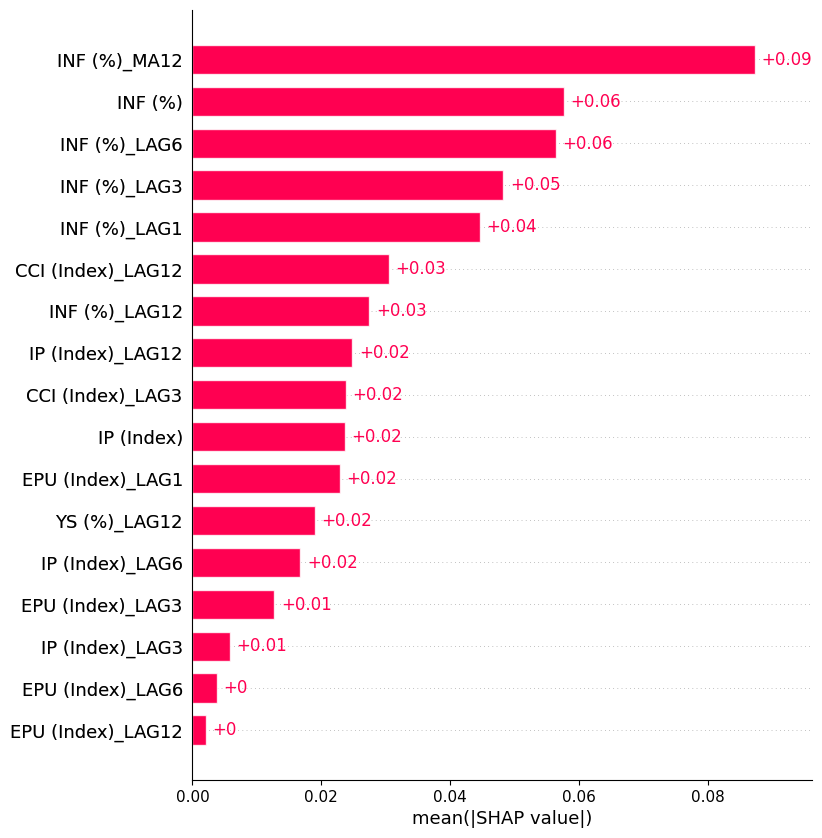

In [211]:
shap.plots.bar(
    shap.Explanation(
        values=shap_array,
        base_values=shap_values.base_values[:, 1],
        data=X_train.values,
        feature_names=X_train.columns
    ),
    max_display=20,
    show=True
)

### Store the results on a dataframe for display
- Store final results in a list of dictionaries, then convert to DataFrame
- Each row logs performance metrics for a single country-target pair


In [212]:
all_results.append({
    "Country": country,
    "Target": target,
    "AUC": auc,
    "F1": f1,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "Threshold": best_thresh,

})
results_df = pd.DataFrame(all_results)
results_df